In [ ]:
#Code was created with the assistance of Microsft Copilot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#########################################################################
# 0. PARAMETER SETUP
#########################################################################



#########################################################################
# 1. INITIALIZATION
#########################################################################

##def init_simulation(N, L, min_gap=7.0):
##    vel = np.zeros(N)
#    pos = np.zeros(N)
#    dv = np.zeros(N)
#    headway = np.zeros(N)
#    length  = 5.0

    # place cars evenly on the ring
 #   spacing = L / N
 #   for i in range(N):
 #       pos[i] = i * spacing
 #       pos[i] = np.arange(N) * spacing
 #       pos[i] += noise * spacing * np.random.randn(N)
 #       pos[i] %= L
 #       pos[i] = np.sort(pos)



    # compute initial headways
 #   for i in range(N):
 #       lead = (i + 1) % N
 #       headway[i] = (pos[lead] - pos[i] - length) % L

 #   print(N, 'Cars initialised')
 #   return vel, pos, dv, headway




    # dv = v_follower - v_leader (canonical IDM Δv = v - v_leader)
   # vel_leader = np.roll(vel, -1)
   # dv = vel - vel_leader

    # Headway = front-bumper gap (subtract vehicle length)
   # headway = np.roll(pos, -1) - pos - length
   # headway[headway < min_gap] = min_gap

def init_simulation(N, L, noise=0.0, params=None):
   # if params is None:
 #       raise ValueError("params must be provided")
#    length  = params[7]
#
#    min_gap = params[4]

#    # 1. Initial speeds: all zero (or all at splim if you prefer)
#    vel = np.zeros(N)
#    # vel = np.ones(N) * (1.0 / params[0])   # if you want all at v0

    # 2. Perfectly even spacing on the ring
#    spacing = L / N
 #   pos = np.arange(N) * spacing

    # 3. Headway and dv
  #  vel_leader = np.roll(vel, -1)
 #   dv = vel - vel_leader

 #   raw_gap = np.roll(pos, -1) - pos - length
 #   headway = (raw_gap + L) % L
 #   headway[headway < min_gap] = min_gap


    vel= np.zeros(N)          # initial velocity - all cars stationary
  #pos= np.linspace(0, L - 10, N) + np.random.uniform(-2, 2, N) #random differences in initial posi
    pos = [12]
    for i in range(1,N):
        pos.append(pos[i-1]+6.5)
    dv= np.zeros(N)        # speed differential
    headway= np.zeros(N)      # headway (what is it for leading car?) - initially 0

  #print(N,' Cars initialised')

    for i in range(N):
        next_car = (i + 1) % N
        headway[i] = (pos[next_car] - pos[i]) -4.5
        #headway[i] = (pos[i] - pos[i-1])- 4.5
        if headway[i] < 0:
            headway[i] += L

    print(f"{N} cars initialized")
    return vel, pos, dv, headway



#########################################################################
# 2. IDM UPDATE: POSITIONS & VELOCITIES
#########################################################################

def upd_pos_vel(Ncar, pos, vel, acc, headway, dv, posnew, velnew, params):
    des_speed_inv = params[0]
    acc_exp       = params[1]
    time_gap      = params[2]
    comf_decel    = params[3]
    min_gap       = params[4]
    acc_max       = params[5]
    del_t         = params[6]

    sqrt_ab = np.sqrt(acc_max * comf_decel)

    for i in range(Ncar):
        s_star = min_gap + max(0.0, vel[i]*time_gap + (vel[i]*dv[i]) / (2*sqrt_ab))

        if headway[i] > 0:
            acc[i] = acc_max * (
                1.0
                - (vel[i] * des_speed_inv) ** acc_exp
                - (s_star / headway[i]) ** 2
            )
        else:
            acc[i] = -comf_decel

    for i in range(Ncar):
        v_end = vel[i] + acc[i] * del_t

        if v_end <= 0:
            if acc[i] < 0:
                t_stop = -vel[i] / acc[i]
                t_stop = np.clip(t_stop, 0, del_t)
                posnew[i] = pos[i] + vel[i]*t_stop + 0.5*acc[i]*t_stop**2
            else:
                posnew[i] = pos[i]
            velnew[i] = 0.0
        else:
            posnew[i] = pos[i] + vel[i]*del_t + 0.5*acc[i]*del_t**2
            velnew[i] = v_end


    return posnew, velnew, acc


#########################################################################
# 3. UPDATE CARS (COMMIT STATE)
#########################################################################

def update_cars(Ncar, pos, vel, posnew, velnew, headway, dv, params):
  # Updates positions, velocities, headways, and velocity differences on a circular road
    length  = params[7]
    L       = params[8]
    min_gap = params[4]

    # Commit positions and velocities with ring wrap
    for i in range(Ncar):
        pos[i] = posnew[i] %L
        vel[i] = velnew[i]

    # Recompute headway and dv
    for i in range(Ncar):
      lead_car= (i+1) % Ncar # ensures ring structure
      # Calculate gap from current car to the car in front, accounting for car length
      headway[i] =  (pos[lead_car]-pos[i]-length) %L
      dv[i] = vel[i] - vel[lead_car]

    return pos, vel, headway, dv


#########################################################################
# 4. GLOBAL FLOW & DENSITY (SPACE-MEAN SPEED)
#########################################################################
def flow_global(Ncar, velnew, road_l):
    # density in cars/km
    dens = Ncar / (road_l / 1000.0)

    # SIMPLE ARITHMETIC MEAN SPEED (like your first code)
    avg_velocity = np.mean(velnew)          # m/s
    flow = dens * avg_velocity * 3.6        # cars/hour

    return dens, flow



#########################################################################
# 5. DETECTOR LOOP
#########################################################################

def detect_loop(Ncar, pos, vel, acc, posnew, velnew,
                track_det_time, track_det_vel,
                det_point, time_pass, del_t):
    for i in range(Ncar):
        # simple non-wrapping detector crossing
        if pos[i] < det_point <= posnew[i]:
            fraction = (det_point - pos[i]) / (posnew[i] - pos[i])
            t_crossed = time_pass + fraction * del_t
            v_crossed = vel[i] + (velnew[i] - vel[i]) * fraction
            track_det_time.append(t_crossed)
            track_det_vel.append(v_crossed)
    return track_det_time, track_det_vel


#########################################################################
# 6. SINGLE STEP
#########################################################################

def Step(N, pos, vel, headway, dv, params,
         time_pass, steps_measure, det_point,
         track_det_time, track_det_vel):
    posnew = np.zeros(N)
    velnew = np.zeros(N)
    acc    = np.zeros(N)
    del_t  = params[6]

    # 1: Update positions, velocities, and compute acceleration
    posnew, velnew, acc = upd_pos_vel(N, pos, vel, acc, headway, dv, posnew, velnew, params)

    # 2: Check for detection events if measurement period has started
    if time_pass >= steps_measure * del_t:
        track_det_time, track_det_vel = detect_loop(
            N, pos, vel, acc, posnew, velnew,
            track_det_time, track_det_vel,
            det_point, time_pass, del_t
        )

    # 3: Compute global flow/density if measurement period has started
    if time_pass >= steps_measure * del_t:
        L_m = params[8]
        dens, flo = flow_global(N, velnew, L_m)
    else:
        dens, flo = 0.0, 0.0

    # 4: Update car states for the next time step
    pos, vel, headway, dv = update_cars(N, pos, vel, posnew, velnew, headway, dv, params)

    return pos, vel, headway, dv, dens, flo, track_det_time, track_det_vel, acc


#########################################################################
# 7. ANALYSIS: GLOBAL & LOCAL
#########################################################################

def analyse_global(track_flow, track_dens):
    if len(track_flow) > 0:
        glob_flow = np.mean(track_flow)
    else:
        glob_flow = 0.0
    if len(track_dens) > 0:
        glob_dens = np.mean(track_dens)
    else:
        glob_dens = 0.0
    return glob_flow, glob_dens


def analyse_local(track_det_time, track_det_vel, steps_measure, del_t, steps):
    measurement_duration = (steps - steps_measure) * del_t
    num_detections = len(track_det_time)
    if measurement_duration > 0:
        local_flow = (num_detections / measurement_duration) * 3600.0  # veh/h
    else:
        local_flow = 0.0

    local_av_speed = np.mean(track_det_vel) if num_detections > 0 else 0.0  # m/s
    if local_av_speed > 0:
        local_av_speed_kmh = local_av_speed * 3.6
        local_dens = local_flow / local_av_speed_kmh  # veh/km via q = k v
    else:
        local_av_speed_kmh = 0.0
        local_dens = 0.0

    return local_flow, local_dens, local_av_speed_kmh


#########################################################################
# 8. ONE FULL SIMULATION RUN
#########################################################################

def Simulate_IDM(N, params, steps, steps_measure, det_point):
    L         = params[8]
    del_t     = params[6]

    track_det_time = []
    track_det_vel  = []
    track_flow     = []
    track_dens     = []

    vel, pos, dv, headway = init_simulation(N, L, params=params)

    positions_history = np.zeros((steps, N))
    vel_history       = np.zeros((steps, N))
    acc_history       = np.zeros((steps, N))

    for i in range(steps):
        time_pass = i * del_t
        pos, vel, headway, dv, dens, flo, track_det_time, track_det_vel, acc = Step(
            N, pos, vel, headway, dv, params,
            time_pass, steps_measure, det_point,
            track_det_time, track_det_vel
        )

        positions_history[i, :] = pos
        vel_history[i, :]       = vel
        acc_history[i, :]       = acc

        if time_pass >= steps_measure * del_t:
            track_flow.append(flo)
            track_dens.append(dens)

    glob_flow, glob_dens = analyse_global(track_flow, track_dens)
    loc_flow, loc_dens, loc_av_speed = analyse_local(
        track_det_time, track_det_vel, steps_measure, del_t, steps
    )

    print("Simulation for car total", N, "completed")
    return glob_flow, glob_dens, loc_flow, loc_dens, loc_av_speed, positions_history, acc_history, vel_history


#########################################################################
# 10. ANIMATION (no artificial rotation)
#########################################################################

def animate_ring(positions, L, interval=30, frame_skip=50):
    import matplotlib.animation as animation

    Nsteps, Ncars = positions.shape
    frames = list(range(0, Nsteps, frame_skip))

    def pos_to_angle(pos):
        return 2 * np.pi * pos / L

    fig, ax = plt.subplots(figsize=(5, 5), dpi=60)

    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')

    theta = np.linspace(0, 2 * np.pi, 500)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)

    car_dots, = ax.plot([], [], 'ro', markersize=8)

    def update(frame):
        pos = positions[frame]
        angles = pos_to_angle(pos)
        x = np.cos(angles)
        y = np.sin(angles)
        car_dots.set_data(x, y)
        return car_dots,

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=False
    )

    return ani


2 cars initialized
Simulation for car total 2 completed
4 cars initialized
Simulation for car total 4 completed
6 cars initialized
Simulation for car total 6 completed
8 cars initialized
Simulation for car total 8 completed
10 cars initialized
Simulation for car total 10 completed
12 cars initialized
Simulation for car total 12 completed
14 cars initialized
Simulation for car total 14 completed
16 cars initialized
Simulation for car total 16 completed
18 cars initialized
Simulation for car total 18 completed
20 cars initialized
Simulation for car total 20 completed
22 cars initialized
Simulation for car total 22 completed
24 cars initialized
Simulation for car total 24 completed
26 cars initialized
Simulation for car total 26 completed
28 cars initialized
Simulation for car total 28 completed
30 cars initialized
Simulation for car total 30 completed
32 cars initialized
Simulation for car total 32 completed
34 cars initialized
Simulation for car total 34 completed
36 cars initialized
Si

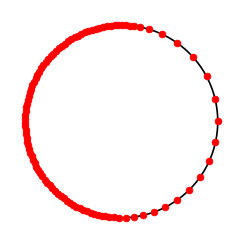

<Figure size 1400x400 with 0 Axes>

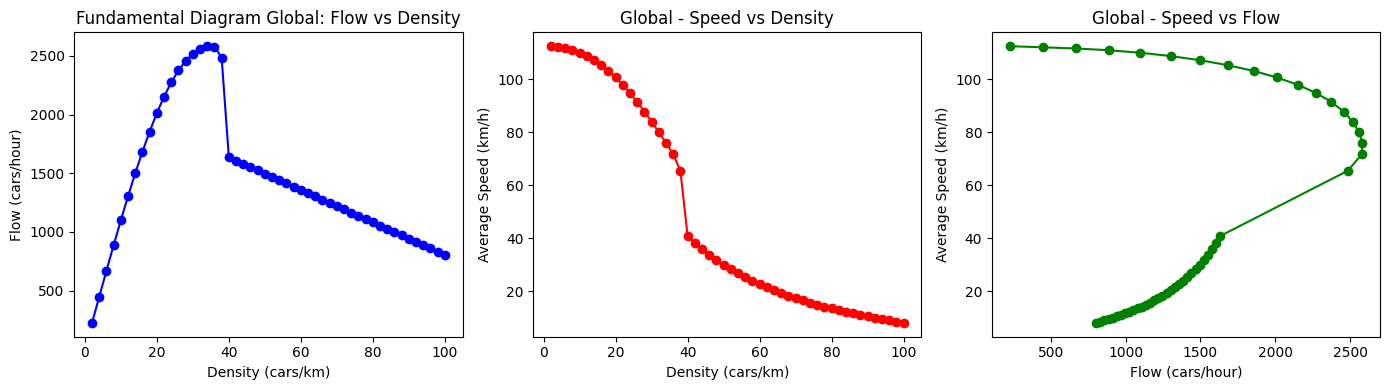

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def init_params():
    Nmax          = 100
    L             = 1000.0
    steps         = 2000
    steps_measure = 500
    splim         = 31.3
    det_point     = 300.0




    params = params_setup(splim, L)
    return Nmax, L, steps, steps_measure, splim, params, det_point


def params_setup(splim,L):
  # key parameters - Fill in yourself
    des_speed=splim              # Desired speed
    des_speed_inv=1./splim       # Multiplication is faster than division
    del_t=  0.5                     # Time step in seconds
    acc_exp= 5.0                     # Acceleration exponent
    time_gap=  1                 # Time gap in seconds
    min_gap= 2.0                # Spatial gap in meters
    comf_decel= 1.5                 # Braking parameter in m/s2
    acc_max=  1.0                   # Maximum acceleration in m/s2
    length =  4.5                   # Car length in m


#1.67

    params = []
    params.append(des_speed_inv)  # 0
    params.append(acc_exp)        # 1
    params.append(time_gap)       # 2
    params.append(comf_decel)     # 3
    params.append(min_gap)        # 4
    params.append(acc_max)        # 5
    params.append(del_t)          # 6
    params.append(length)         # 7
    params.append(L)              # 8
    return params








#########################################################################
# 9. MAIN SWEEP OVER NUMBER OF CARS
#########################################################################

Nmax, L, steps, steps_measure, splim, params, det_point = init_params()

start_cars = 2
end_cars   = Nmax + 1
step_cars  = 2

global_flow_list   = []
global_dens_list   = []
global_av_vel_list = []
local_flow_list    = []
local_dens_list    = []
local_av_vel_list  = []

positions_for_animation = None

for N in range(start_cars, end_cars, step_cars):
    glob_flow, glob_dens, loc_flow, loc_dens, loc_av_speed, positions_history, acc_history, vel_history = Simulate_IDM(
        N, params, steps, steps_measure, det_point
    )

    if N == Nmax:
        positions_for_animation = positions_history  # <- fixed

    global_flow_list.append(glob_flow)
    global_dens_list.append(glob_dens)
    local_flow_list.append(loc_flow)
    local_dens_list.append(loc_dens)
    local_av_vel_list.append(loc_av_speed)

    if glob_dens > 0:
        global_av_vel_list.append(glob_flow / glob_dens)
    else:
        global_av_vel_list.append(0.0)


# -----------------------------
# Animate AFTER the sweep
# -----------------------------
anim = animate_ring(positions_for_animation, L, frame_skip=50)

from matplotlib.animation import PillowWriter
anim.save("ring.gif", writer=PillowWriter(fps=20))

print(len(range(0, positions_for_animation.shape[0], 50)))

from IPython.display import Image
Image(filename="ring.gif")

print(positions_for_animation[0][:5])
print(positions_for_animation[1][:5])
print(positions_for_animation[2][:5])

plt.figure(figsize=(14,4))

#plt.subplot(1,3,1)
#plt.plot(global_dens, global_flow, 'bo-')
#plt.xlabel("Density (cars/km)")
#plt.ylabel("Flow (cars/hour)")
#plt.title("Fundamental Diagram: Flow vs Density")

#plt.subplot(1,3,2)
#plt.plot(global_dens, global_av_vel, 'ro-')
#plt.xlabel("Density (cars/km)")
#plt.ylabel("Average Speed (km/h)")
#plt.title("Speed vs Density")

#plt.subplot(1,3,3)
#plt.plot(global_flow, global_av_vel, 'go-')
#plt.xlabel("Flow (cars/hour)")
#plt.ylabel("Average Speed (km/h)")
#plt.title("Speed vs Flow")

#plt.tight_layout()
#plt.show()


plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(global_dens_list, global_flow_list, 'bo-')
plt.xlabel("Density (cars/km)")
plt.ylabel("Flow (cars/hour)")
plt.title("Fundamental Diagram Global: Flow vs Density")

plt.subplot(1,3,2)
plt.plot(global_dens_list, global_av_vel_list, 'ro-')
plt.xlabel("Density (cars/km)")
plt.ylabel("Average Speed (km/h)")
plt.title("Global - Speed vs Density")

plt.subplot(1,3,3)
plt.plot(global_flow_list, global_av_vel_list, 'go-')
plt.xlabel("Flow (cars/hour)")
plt.ylabel("Average Speed (km/h)")
plt.title("Global - Speed vs Flow")

plt.tight_layout()
plt.show()


In [ ]:
#traffic

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#########################################################################
# 0. PARAMETER SETUP
#########################################################################
def light_phase(t, red_time, green_time, yellow_time):
    cycle = red_time + green_time + yellow_time
    t_mod = t % cycle
    if t_mod < red_time:
        return "red"
    elif t_mod < red_time + green_time:
        return "green"
    else:
        return "yellow"




#########################################################################
# 1. INITIALIZATION
#########################################################################

##def init_simulation(N, L, min_gap=7.0):
##    vel = np.zeros(N)
#    pos = np.zeros(N)
#    dv = np.zeros(N)
#    headway = np.zeros(N)
#    length  = 5.0

    # place cars evenly on the ring
 #   spacing = L / N
 #   for i in range(N):
 #       pos[i] = i * spacing
 #       pos[i] = np.arange(N) * spacing
 #       pos[i] += noise * spacing * np.random.randn(N)
 #       pos[i] %= L
 #       pos[i] = np.sort(pos)



    # compute initial headways
 #   for i in range(N):
 #       lead = (i + 1) % N
 #       headway[i] = (pos[lead] - pos[i] - length) % L

 #   print(N, 'Cars initialised')
 #   return vel, pos, dv, headway




    # dv = v_follower - v_leader (canonical IDM Δv = v - v_leader)
   # vel_leader = np.roll(vel, -1)
   # dv = vel - vel_leader

    # Headway = front-bumper gap (subtract vehicle length)
   # headway = np.roll(pos, -1) - pos - length
   # headway[headway < min_gap] = min_gap

def init_simulation(N, L, noise=0.0, params=None):



    vel= np.zeros(N)          # initial velocity - all cars stationary
  #pos= np.linspace(0, L - 10, N) + np.random.uniform(-2, 2, N) #random differences in initial posi
    pos = [12]
    for i in range(1,N):
        pos.append(pos[i-1]+6.5)
    dv= np.zeros(N)        # speed differential
    headway= np.zeros(N)      # headway (what is it for leading car?) - initially 0

  #print(N,' Cars initialised')

    for i in range(N):
        next_car = (i + 1) % N
        headway[i] = (pos[next_car] - pos[i]) -4.5
        #headway[i] = (pos[i] - pos[i-1])- 4.5
        if headway[i] < 0:
            headway[i] += L

    print(f"{N} cars initialized")
    return vel, pos, dv, headway



#########################################################################
# 2. IDM UPDATE: POSITIONS & VELOCITIES
#########################################################################

def upd_pos_vel(Ncar, pos, vel, acc, headway, dv, posnew, velnew, params):
    des_speed_inv = params[0]
    acc_exp       = params[1]
    time_gap      = params[2]
    comf_decel    = params[3]
    min_gap       = params[4]
    acc_max       = params[5]
    del_t         = params[6]

    sqrt_ab = np.sqrt(acc_max * comf_decel)

    for i in range(Ncar):
        s_star = min_gap + max(0.0, vel[i]*time_gap + (vel[i]*dv[i]) / (2*sqrt_ab))

        if headway[i] > 0:
            acc[i] = acc_max * (
                1.0
                - (vel[i] * des_speed_inv) ** acc_exp
                - (s_star / headway[i]) ** 2
            )
        else:
            acc[i] = -comf_decel

    for i in range(Ncar):
        v_end = vel[i] + acc[i] * del_t

        if v_end <= 0:
            if acc[i] < 0:
                t_stop = -vel[i] / acc[i]
                t_stop = np.clip(t_stop, 0, del_t)
                posnew[i] = pos[i] + vel[i]*t_stop + 0.5*acc[i]*t_stop**2
            else:
                posnew[i] = pos[i]
            velnew[i] = 0.0
        else:
            posnew[i] = pos[i] + vel[i]*del_t + 0.5*acc[i]*del_t**2
            velnew[i] = v_end


    return posnew, velnew, acc


#########################################################################
# 3. UPDATE CARS (COMMIT STATE)
#########################################################################


def update_cars(Ncar, pos, vel, posnew, velnew,
                headway, dv, params, time_pass,
                light_position, red_time, green_time, yellow_time):
  # Updates positions, velocities, headways, and velocity differences on a circular road
    length  = params[7]
    L       = params[8]
    min_gap = params[4]
    comf_decel = params[3]

    # Commit positions and velocities with ring wrap
    for i in range(Ncar):
        pos[i] = posnew[i] %L
        vel[i] = velnew[i]

    # Recompute headway and dv
    for i in range(Ncar):
      lead_car= (i+1) % Ncar # ensures ring structure
      # Calculate gap from current car to the car in front, accounting for car length
      headway[i] =  (pos[lead_car]-pos[i]-length) %L
      dv[i] = vel[i] - vel[lead_car]

    # ---------------------------------------------------------
    # 3. Traffic-light constraint (virtual leader)
    # ---------------------------------------------------------
    phase = light_phase(time_pass, red_time, green_time, yellow_time)

    headway_light = np.full(Ncar, np.inf)
    dv_light      = np.zeros(Ncar)

    for i in range(Ncar):
        dist_to_light = (light_position - pos[i]) % L - length
        if dist_to_light <= 0:
            continue

        v = vel[i]

        if phase == "green":
            continue

        if phase == "red":
            headway_light[i] = max(dist_to_light, min_gap)
            dv_light[i] = v - 0.0
            continue

        if phase == "yellow":
            d_stop = v*v / (2.0 * comf_decel)
            t_reach = dist_to_light / max(v, 1e-6)

            cycle = red_time + green_time + yellow_time
            t_mod = time_pass % cycle
            t_yellow_left = cycle - t_mod

            must_stop = (d_stop >= dist_to_light) or (t_reach > t_yellow_left)

            if must_stop:
                headway_light[i] = max(dist_to_light, min_gap)
                dv_light[i] = v - 0.0

    # ---------------------------------------------------------
    # 4. Combine real leader and virtual light
    # ---------------------------------------------------------
    for i in range(Ncar):
        if headway_light[i] < headway[i]:
            headway[i] = headway_light[i]
            dv[i]      = dv_light[i]


    return pos, vel, headway, dv


#########################################################################
# 4. GLOBAL FLOW & DENSITY (SPACE-MEAN SPEED)
#########################################################################
def flow_global(Ncar, velnew, road_l):
    # density in cars/km
    dens = Ncar / (road_l / 1000.0)

    # SIMPLE ARITHMETIC MEAN SPEED (like your first code)
    avg_velocity = np.mean(velnew)          # m/s
    flow = dens * avg_velocity * 3.6        # cars/hour

    return dens, flow



#########################################################################
# 5. DETECTOR LOOP
#########################################################################

def detect_loop(Ncar, pos, vel, acc, posnew, velnew,
                track_det_time, track_det_vel,
                det_point, time_pass, del_t):
    for i in range(Ncar):
        # simple non-wrapping detector crossing
        if pos[i] < det_point <= posnew[i]:
            fraction = (det_point - pos[i]) / (posnew[i] - pos[i])
            t_crossed = time_pass + fraction * del_t
            v_crossed = vel[i] + (velnew[i] - vel[i]) * fraction
            track_det_time.append(t_crossed)
            track_det_vel.append(v_crossed)
    return track_det_time, track_det_vel


#########################################################################
# 6. SINGLE STEP
#########################################################################

def Step(N, pos, vel, headway, dv, params,
         time_pass, steps_measure, det_point,
         track_det_time, track_det_vel,
         light_position, red_time, green_time, yellow_time):

    posnew = np.zeros(N)
    velnew = np.zeros(N)
    acc    = np.zeros(N)
    del_t  = params[6]

    # 1: Update positions, velocities, and compute acceleration
    posnew, velnew, acc = upd_pos_vel(N, pos, vel, acc, headway, dv, posnew, velnew, params)

    # 2: Check for detection events if measurement period has started
    if time_pass >= steps_measure * del_t:
        track_det_time, track_det_vel = detect_loop(
            N, pos, vel, acc, posnew, velnew,
            track_det_time, track_det_vel,
            det_point, time_pass, del_t
        )

    # 3: Compute global flow/density if measurement period has started
    if time_pass >= steps_measure * del_t:
        L_m = params[8]
        dens, flo = flow_global(N, velnew, L_m)
    else:
        dens, flo = 0.0, 0.0

    # 4: Update car states for the next time step
    pos, vel, headway, dv = update_cars(
    N, pos, vel, posnew, velnew,
    headway, dv, params,
    time_pass,
    light_position, red_time, green_time, yellow_time
)


    return pos, vel, headway, dv, dens, flo, track_det_time, track_det_vel, acc


#########################################################################
# 7. ANALYSIS: GLOBAL & LOCAL
#########################################################################

def analyse_global(track_flow, track_dens):
    if len(track_flow) > 0:
        glob_flow = np.mean(track_flow)
    else:
        glob_flow = 0.0
    if len(track_dens) > 0:
        glob_dens = np.mean(track_dens)
    else:
        glob_dens = 0.0
    return glob_flow, glob_dens


def analyse_local(track_det_time, track_det_vel, steps_measure, del_t, steps):
    measurement_duration = (steps - steps_measure) * del_t
    num_detections = len(track_det_time)
    if measurement_duration > 0:
        local_flow = (num_detections / measurement_duration) * 3600.0  # veh/h
    else:
        local_flow = 0.0

    local_av_speed = np.mean(track_det_vel) if num_detections > 0 else 0.0  # m/s
    if local_av_speed > 0:
        local_av_speed_kmh = local_av_speed * 3.6
        local_dens = local_flow / local_av_speed_kmh  # veh/km via q = k v
    else:
        local_av_speed_kmh = 0.0
        local_dens = 0.0

    return local_flow, local_dens, local_av_speed_kmh


#########################################################################
# 8. ONE FULL SIMULATION RUN
#########################################################################

def Simulate_IDM(N, params, steps, steps_measure,
                 light_position, red_time, green_time, yellow_time):
    L         = params[8]
    del_t     = params[6]

    track_det_time = []
    track_det_vel  = []
    track_flow     = []
    track_dens     = []

    vel, pos, dv, headway = init_simulation(N, L, params=params)

    positions_history = np.zeros((steps, N))
    vel_history       = np.zeros((steps, N))
    acc_history       = np.zeros((steps, N))

    for i in range(steps):
        time_pass = i * del_t
        pos, vel, headway, dv, dens, flo, track_det_time, track_det_vel, acc = Step(
    N, pos, vel, headway, dv, params,
    time_pass, steps_measure, det_point,
    track_det_time, track_det_vel,
    light_position, red_time, green_time, yellow_time
)


        positions_history[i, :] = pos
        vel_history[i, :]       = vel
        acc_history[i, :]       = acc

        if time_pass >= steps_measure * del_t:
            track_flow.append(flo)
            track_dens.append(dens)

    glob_flow, glob_dens = analyse_global(track_flow, track_dens)
    loc_flow, loc_dens, loc_av_speed = analyse_local(
        track_det_time, track_det_vel, steps_measure, del_t, steps
    )

    print("Simulation for car total", N, "completed")
    return glob_flow, glob_dens, loc_flow, loc_dens, loc_av_speed, positions_history, acc_history, vel_history


#########################################################################
# 10. ANIMATION (no artificial rotation)
#########################################################################

def animate_ring(positions, L, interval=30, frame_skip=50):
    import matplotlib.animation as animation

    Nsteps, Ncars = positions.shape
    frames = list(range(0, Nsteps, frame_skip))

    def pos_to_angle(pos):
        return 2 * np.pi * pos / L

    fig, ax = plt.subplots(figsize=(5, 5), dpi=60)

    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')

    theta = np.linspace(0, 2 * np.pi, 500)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)

    car_dots, = ax.plot([], [], 'ro', markersize=8)

    def update(frame):
        pos = positions[frame]
        angles = pos_to_angle(pos)
        x = np.cos(angles)
        y = np.sin(angles)
        car_dots.set_data(x, y)
        return car_dots,

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=False
    )

    return ani


2 cars initialized
Simulation for car total 2 completed
4 cars initialized
Simulation for car total 4 completed
6 cars initialized
Simulation for car total 6 completed
8 cars initialized
Simulation for car total 8 completed
10 cars initialized
Simulation for car total 10 completed
12 cars initialized
Simulation for car total 12 completed
14 cars initialized
Simulation for car total 14 completed
16 cars initialized
Simulation for car total 16 completed
18 cars initialized
Simulation for car total 18 completed
20 cars initialized
Simulation for car total 20 completed
22 cars initialized
Simulation for car total 22 completed
24 cars initialized
Simulation for car total 24 completed
26 cars initialized
Simulation for car total 26 completed
28 cars initialized
Simulation for car total 28 completed
30 cars initialized
Simulation for car total 30 completed
32 cars initialized
Simulation for car total 32 completed
34 cars initialized
Simulation for car total 34 completed
36 cars initialized
Si

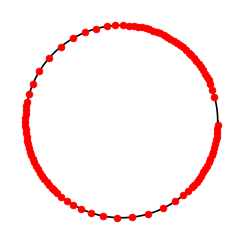

<Figure size 1400x400 with 0 Axes>

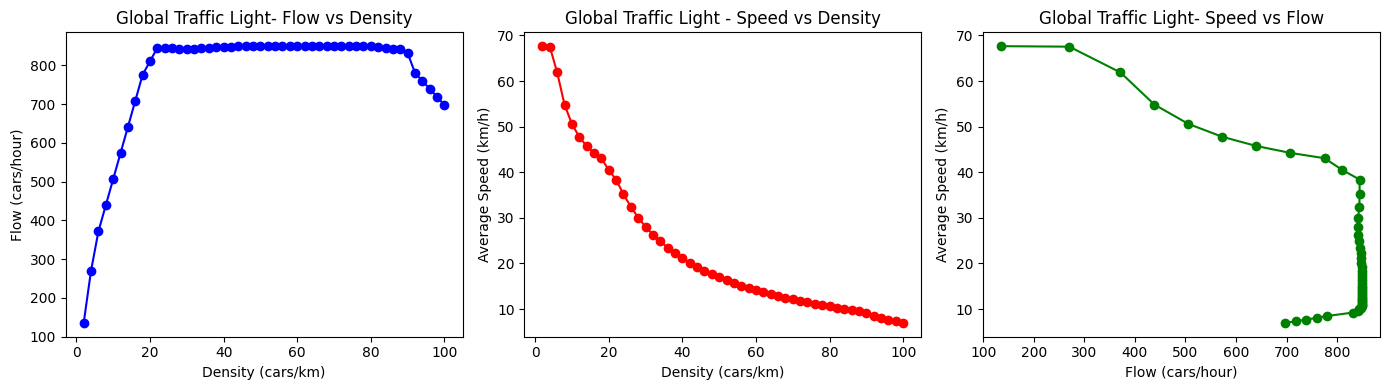

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def init_params():
    Nmax          = 100
    L             = 1000.0
    steps         = 2000
    steps_measure = 500
    splim         = 31.3
    det_point     = 300.0
    light_position = 1000.0   # where the light is on the ring
    red_time = 40.0          # seconds
    green_time = 60.0        # seconds
   # cycle_time = red_time + green_time
    yellow_time = 5.0   # seconds
    cycle_time = red_time + green_time + yellow_time





    params = params_setup(splim, L)
    return Nmax, L, steps, steps_measure, splim, params, det_point, light_position, red_time, green_time, yellow_time


def params_setup(splim,L):
  # key parameters - Fill in yourself
    des_speed=splim              # Desired speed
    des_speed_inv=1./splim       # Multiplication is faster than division
    del_t=  0.5                     # Time step in seconds
    acc_exp= 5.0                     # Acceleration exponent
    time_gap=  1                 # Time gap in seconds
    min_gap= 2.0                # Spatial gap in meters
    comf_decel= 1.5                 # Braking parameter in m/s2
    acc_max=  1.0                   # Maximum acceleration in m/s2
    length =  4.5                   # Car length in m



#1.67

    params = []
    params.append(des_speed_inv)  # 0
    params.append(acc_exp)        # 1
    params.append(time_gap)       # 2
    params.append(comf_decel)     # 3
    params.append(min_gap)        # 4
    params.append(acc_max)        # 5
    params.append(del_t)          # 6
    params.append(length)         # 7
    params.append(L)              # 8
    return params








#########################################################################
# 9. MAIN SWEEP OVER NUMBER OF CARS
#########################################################################

Nmax, L, steps, steps_measure, splim, params, det_point, light_position, red_time, green_time, yellow_time = init_params()

start_cars = 2
end_cars   = Nmax + 1
step_cars  = 2

global_flow_list   = []
global_dens_list   = []
global_av_vel_list = []
local_flow_list    = []
local_dens_list    = []
local_av_vel_list  = []

positions_for_animation = None

for N in range(start_cars, end_cars, step_cars):
    glob_flow, glob_dens, loc_flow, loc_dens, loc_av_speed, positions_history, acc_history, vel_history = Simulate_IDM(
        N, params, steps, steps_measure,
                 light_position, red_time, green_time, yellow_time
    )

    if N == Nmax:
        positions_for_animation = positions_history  # <- fixed

    global_flow_list.append(glob_flow)
    global_dens_list.append(glob_dens)
    local_flow_list.append(loc_flow)
    local_dens_list.append(loc_dens)
    local_av_vel_list.append(loc_av_speed)

    if glob_dens > 0:
        global_av_vel_list.append(glob_flow / glob_dens)
    else:
        global_av_vel_list.append(0.0)


# -----------------------------
# Animate AFTER the sweep
# -----------------------------
anim = animate_ring(positions_for_animation, L, frame_skip=50)

from matplotlib.animation import PillowWriter
anim.save("ring.gif", writer=PillowWriter(fps=20))

print(len(range(0, positions_for_animation.shape[0], 50)))

from IPython.display import Image
Image(filename="ring.gif")

print(positions_for_animation[0][:5])
print(positions_for_animation[1][:5])
print(positions_for_animation[2][:5])

plt.figure(figsize=(14,4))

#plt.subplot(1,3,1)
#plt.plot(global_dens, global_flow, 'bo-')
#plt.xlabel("Density (cars/km)")
#plt.ylabel("Flow (cars/hour)")
#plt.title("Fundamental Diagram: Flow vs Density")

#plt.subplot(1,3,2)
#plt.plot(global_dens, global_av_vel, 'ro-')
#plt.xlabel("Density (cars/km)")
#plt.ylabel("Average Speed (km/h)")
#plt.title("Speed vs Density")

#plt.subplot(1,3,3)
#plt.plot(global_flow, global_av_vel, 'go-')
#plt.xlabel("Flow (cars/hour)")
#plt.ylabel("Average Speed (km/h)")
#plt.title("Speed vs Flow")

#plt.tight_layout()
#plt.show()


plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(global_dens_list, global_flow_list, 'bo-')
plt.xlabel("Density (cars/km)")
plt.ylabel("Flow (cars/hour)")
plt.title("Global Traffic Light- Flow vs Density")

plt.subplot(1,3,2)
plt.plot(global_dens_list, global_av_vel_list, 'ro-')
plt.xlabel("Density (cars/km)")
plt.ylabel("Average Speed (km/h)")
plt.title("Global Traffic Light - Speed vs Density")

plt.subplot(1,3,3)
plt.plot(global_flow_list, global_av_vel_list, 'go-')
plt.xlabel("Flow (cars/hour)")
plt.ylabel("Average Speed (km/h)")
plt.title("Global Traffic Light- Speed vs Flow")

plt.tight_layout()
plt.show()


2 cars initialized
Simulation for car total 2 completed
4 cars initialized
Simulation for car total 4 completed
6 cars initialized
Simulation for car total 6 completed
8 cars initialized
Simulation for car total 8 completed
10 cars initialized
Simulation for car total 10 completed
12 cars initialized
Simulation for car total 12 completed
14 cars initialized
Simulation for car total 14 completed
16 cars initialized
Simulation for car total 16 completed
18 cars initialized
Simulation for car total 18 completed
20 cars initialized
Simulation for car total 20 completed
22 cars initialized
Simulation for car total 22 completed
24 cars initialized
Simulation for car total 24 completed
26 cars initialized
Simulation for car total 26 completed
28 cars initialized
Simulation for car total 28 completed
30 cars initialized
Simulation for car total 30 completed
32 cars initialized
Simulation for car total 32 completed
34 cars initialized
Simulation for car total 34 completed
36 cars initialized
Si

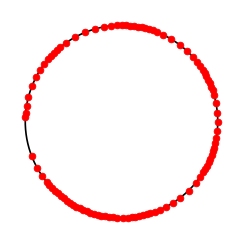

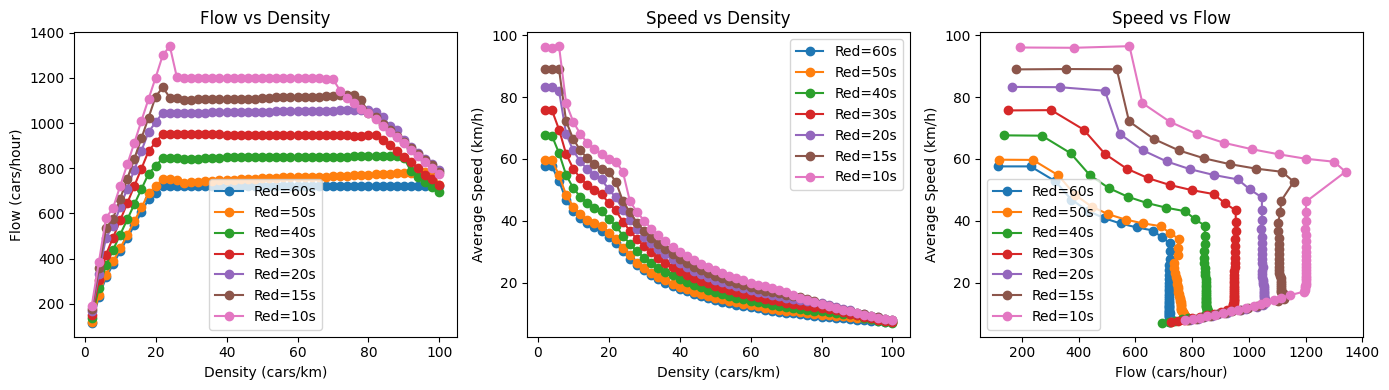

In [ ]:
#lots of lengths
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Parameter initialization
# ---------------------------------------------------------



def params_setup(splim,L):
  # key parameters - Fill in yourself
    des_speed=splim              # Desired speed
    des_speed_inv=1./splim       # Multiplication is faster than division
    del_t=  0.5                     # Time step in seconds
    acc_exp= 5.0                     # Acceleration exponent
    time_gap=  1                 # Time gap in seconds
    min_gap= 2.0                # Spatial gap in meters
    comf_decel= 1.5                 # Braking parameter in m/s2
    acc_max=  1.0                   # Maximum acceleration in m/s2
    length =  4.5                   # Car length in m




#1.67

    params = []
    params.append(des_speed_inv)  # 0
    params.append(acc_exp)        # 1
    params.append(time_gap)       # 2
    params.append(comf_decel)     # 3
    params.append(min_gap)        # 4
    params.append(acc_max)        # 5
    params.append(del_t)          # 6
    params.append(length)         # 7
    params.append(L)              # 8
    return params





def init_params():
    Nmax          = 100
    L             = 1000.0
    steps         = 2000
    steps_measure = 500
    splim         = 31.3

    det_point      = 300.0
    light_position = 500.0

    green_time  = 60.0
    yellow_time = 5.0

    params = params_setup(splim, L)

    return (Nmax, L, steps, steps_measure, splim, params,
            det_point, light_position, green_time, yellow_time)


# ---------------------------------------------------------
# Load parameters
# ---------------------------------------------------------
(Nmax, L, steps, steps_measure, splim, params,
 det_point, light_position, green_time, yellow_time) = init_params()

start_cars = 2
end_cars   = Nmax + 1
step_cars  = 2

# ---------------------------------------------------------
# Choose red-light durations to compare
# ---------------------------------------------------------
#red_times_to_test = [10, 20, 30, 40, 50, 60]
red_times_to_test = [60,50,40,30,20,15,10]

# Dictionary: red_time → (densities, flows, speeds)
all_results = {}

positions_for_animation = None

# ---------------------------------------------------------
# Sweep over red times
# ---------------------------------------------------------
for red_time in red_times_to_test:

    global_flow   = []
    global_dens   = []
    global_av_vel = []

    # Sweep over car counts
    for N in range(start_cars, end_cars, step_cars):

        glob_flow, glob_dens, loc_flow, loc_dens, loc_av_speed, positions_history, acc_history, vel_history = Simulate_IDM(
        N, params, steps, steps_measure,
                 light_position, red_time, green_time, yellow_time
    )

        if N == Nmax:
            positions_for_animation = positions_history

        if glob_flow is None or glob_dens is None or glob_dens <= 0:
            continue

        global_flow.append(glob_flow)
        global_dens.append(glob_dens)
        global_av_vel.append(glob_flow / glob_dens)

    # Store results for this red time
    all_results[red_time] = (np.array(global_dens),
                             np.array(global_flow),
                             np.array(global_av_vel))


# ---------------------------------------------------------
# Animate AFTER the sweep
# ---------------------------------------------------------
anim = animate_ring(positions_for_animation, L, frame_skip=50)

from matplotlib.animation import PillowWriter
anim.save("ring.gif", writer=PillowWriter(fps=20))

print("Frames:", len(range(0, positions_for_animation.shape[0], 50)))

from IPython.display import Image
Image(filename="ring.gif")


# ---------------------------------------------------------
# Plot all curves on the same axes
# ---------------------------------------------------------
plt.figure(figsize=(14,4))

# ---- Flow vs Density ----
plt.subplot(1,3,1)
for red_time, (dens, flow, _) in all_results.items():
    plt.plot(dens, flow, '-o', label=f"Red={red_time}s")
plt.xlabel("Density (cars/km)")
plt.ylabel("Flow (cars/hour)")
plt.title("Flow vs Density")
plt.legend()

# ---- Speed vs Density ----
plt.subplot(1,3,2)
for red_time, (dens, _, av_vel) in all_results.items():
    plt.plot(dens, av_vel, '-o', label=f"Red={red_time}s")
plt.xlabel("Density (cars/km)")
plt.ylabel("Average Speed (km/h)")
plt.title("Speed vs Density")
plt.legend()

# ---- Speed vs Flow ----
plt.subplot(1,3,3)
for red_time, (_, flow, av_vel) in all_results.items():
    plt.plot(flow, av_vel, '-o', label=f"Red={red_time}s")
plt.xlabel("Flow (cars/hour)")
plt.ylabel("Average Speed (km/h)")
plt.title("Speed vs Flow")
plt.legend()

plt.tight_layout()
plt.show()
